# Phase 1: Loading the Cleaned Dataset

In the previous notebook `(01_data_exploration.ipynb)`, we performed data wrangling, handled the class imbalance, and standardized the text. In this phase, we load that processed data to begin the modeling process.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned dataset
# Since this notebook is in the 'notebooks' folder, we go up one level to 'data'
df = pd.read_csv('../data/spam_cleaned.csv')

# Note: Sometimes CSVs save empty strings as 'NaN'. 
# We fill any empty 'clean_text' (which might happen if a message was only stopwords) 
# with a placeholder to avoid errors in the next step.
df['clean_text'] = df['clean_text'].fillna('empty_message')

print("--- Cleaned Data Loaded ---")
print(df.head())
print(f"\nTotal rows: {len(df)}")

--- Cleaned Data Loaded ---
  label                                               text  label_num  \
0   ham  Go until jurong point, crazy.. Available only ...          0   
1   ham                      Ok lar... Joking wif u oni...          0   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...          1   
3   ham  U dun say so early hor... U c already then say...          0   
4   ham  Nah I don't think he goes to usf, he lives aro...          0   

                                          clean_text  text_len  
0  go jurong point crazy available bugis n great ...       111  
1                            ok lar joking wif u oni        29  
2  free entry 2 wkly comp win fa cup final tkts 2...       155  
3                u dun say early hor u c already say        49  
4        nah dont think goes usf lives around though        61  

Total rows: 5572


# Phase 2: Splitting the Dataset

Before we convert text to numbers, we must split our data into two parts:

1. Training Set (80%): Used to teach the model.

2. Testing Set (20%): Used to evaluate the model (the "Final Exam").

This prevents Overfitting, where a model simply memorizes the training data but fails in the real world.

In [2]:
from sklearn.model_selection import train_test_split

# X is our input (the cleaned text)
# y is our target (the label_num: 0 for ham, 1 for spam)
X = df['clean_text']
y = df['label_num']

# We use a 80/20 split. 
# random_state=42 is like a "seed" that ensures every time you run this, 
# you get the same random split for reproducible results.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Total rows in dataset: {len(df)}")
print(f"Rows for training: {len(X_train)}")
print(f"Rows for testing: {len(X_test)}")

Total rows in dataset: 5572
Rows for training: 4457
Rows for testing: 1115


# Phase 3: Vectorization (TF-IDF)

Machine Learning models can't "read" strings like "free win cup." We must transform these into a numerical matrix. We will use TF-IDF (Term Frequency-Inverse Document Frequency).

Why TF-IDF?

1. Term Frequency (TF): Rewards words that appear often in a single message.

2. Inverse Document Frequency (IDF): Penalizes common words that appear in every message (like "hello" or "me"), making sure truly unique "spam" words (like "claim") stand out.

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the TfidfVectorizer
# We limit the max_features to 2500 to keep the model fast and focused on the most important words.
vectorizer = TfidfVectorizer(max_features=2500)

# 1. We "fit" the vectorizer on the Training Data ONLY.
# This teaches the model the vocabulary of our training set.
X_train_tfidf = vectorizer.fit_transform(X_train)

# 2. We "transform" the Test Data.
# The test data is processed using the vocabulary the model learned during training.
X_test_tfidf = vectorizer.transform(X_test)

# Check the shape of the resulting matrix
# You will see rows (number of messages) and columns (the top 2500 words we selected).
print(f"Shape of training matrix: {X_train_tfidf.shape}")

Shape of training matrix: (4457, 2500)


# Phase 4: Model Training (Naive Bayes)

In this step, we train a Multinomial Naive Bayes model. This algorithm calculates the probability of a message being "Spam" based on the frequency of the words it contains. It is a standard "baseline" model for NLP tasks due to its speed and accuracy with text data.

In [4]:
from sklearn.naive_bayes import MultinomialNB

# 1. Initialize the model
# MultinomialNB is specifically designed for discrete counts (like word frequencies)
model = MultinomialNB()

# 2. Train the model using our TF-IDF training matrix and the corresponding labels
model.fit(X_train_tfidf, y_train)

# 3. Make predictions on the Test set (the data the model hasn't seen yet)
y_pred = model.predict(X_test_tfidf)

print("Model training complete and predictions generated.")

Model training complete and predictions generated.


# Phase 5: Evaluation and Metrics

To fulfill the assessment requirement of "validating results using appropriate metrics," we cannot rely on Accuracy alone. Because our data is imbalanced (mostly Ham), we need to look at:

1. Precision: When the model says "Spam," how often is it right? (Crucial to avoid blocking important real emails).

2. Recall: What percentage of all actual Spam did the model catch?

3. Confusion Matrix: A visual breakdown of correct and incorrect predictions.

Overall Accuracy: 0.9758

--- Detailed Classification Report ---
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.99       965
        Spam       1.00      0.82      0.90       150

    accuracy                           0.98      1115
   macro avg       0.99      0.91      0.94      1115
weighted avg       0.98      0.98      0.97      1115



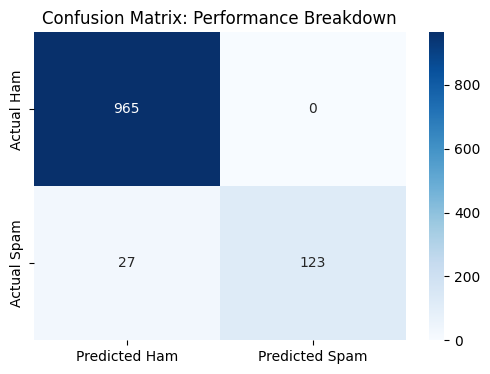

In [5]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Generate the classification report
report = classification_report(y_test, y_pred, target_names=['Ham', 'Spam'])
accuracy = accuracy_score(y_test, y_pred)

print(f"Overall Accuracy: {accuracy:.4f}")
print("\n--- Detailed Classification Report ---")
print(report)

# Create a visual Confusion Matrix
plt.figure(figsize=(6, 4))
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Ham', 'Predicted Spam'], 
            yticklabels=['Actual Ham', 'Actual Spam'])
plt.title('Confusion Matrix: Performance Breakdown')
plt.show()

# Phase 6: Interpreting the Baseline Results

The Multinomial Naive Bayes model serves as our baseline. Based on the evaluation metrics, we can draw the following conclusions for the project report:

1. **High Precision** vs. **Moderate Recall**: The model achieved a Spam Precision of 1.00, meaning it never misclassified a legitimate message as spam. However, the Spam Recall of 0.82 indicates that approximately 18% of spam messages still leaked into the "Ham" category.

2. **The Impact of Class Imbalance**: Even though 86% of our data is "Ham," the model did not simply guess "Ham" every time. It successfully identified the majority of spam, proving that the TF-IDF vectorization effectively captured spam-specific keywords.

3. **The "Safe" Filter**: From a business/user perspective, this model is "safe." It ensures no important emails are lost (Zero False Positives), even if it isn't yet perfect at catching every single junk message.

# Phase 7: Model Comparison — Support Vector Machine (SVM)

To "step out of the comfort zone" and improve our results, we now apply a second algorithm: the **Support Vector Machine (SVM)**.

**Why SVM?**

SVM is a powerful, high-margin classifier. It is often more effective than Naive Bayes when the boundary between classes is complex. We will use the same Training and Testing sets to ensure the comparison is scientifically valid.

In [6]:
from sklearn.svm import SVC

# 1. Initialize the Support Vector Classifier
# We use a 'linear' kernel as it is generally the most effective for text data
svm_model = SVC(kernel='linear', random_state=42)

# 2. Train the SVM model
svm_model.fit(X_train_tfidf, y_train)

# 3. Make predictions
y_pred_svm = svm_model.predict(X_test_tfidf)

print("SVM training complete and predictions generated.")

SVM training complete and predictions generated.


## 7.1 Evaluating the SVM Model

We will now generate the same metrics for the SVM to see if it improves the **Recall** (catching more of those 27 missed spam messages) without sacrificing too much **Precision**.

SVM Overall Accuracy: 0.9794

--- SVM Detailed Classification Report ---
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       965
        Spam       0.98      0.86      0.92       150

    accuracy                           0.98      1115
   macro avg       0.98      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115



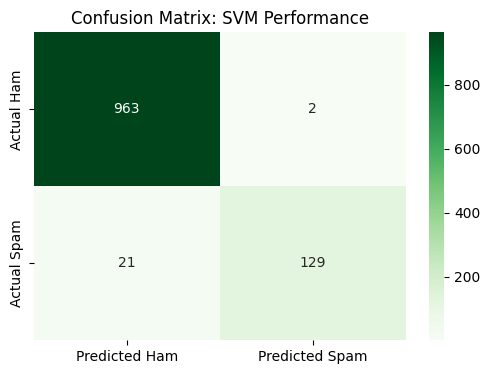

In [7]:
# Generate the classification report for SVM
report_svm = classification_report(y_test, y_pred_svm, target_names=['Ham', 'Spam'])
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print(f"SVM Overall Accuracy: {accuracy_svm:.4f}")
print("\n--- SVM Detailed Classification Report ---")
print(report_svm)

# Visual Confusion Matrix for SVM
plt.figure(figsize=(6, 4))
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(conf_matrix_svm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Predicted Ham', 'Predicted Spam'], 
            yticklabels=['Actual Ham', 'Actual Spam'])
plt.title('Confusion Matrix: SVM Performance')
plt.show()

# Phase 8: Final Comparison Summary

We consolidate the results of both models into a single table. This serves as the primary evidence for the Validation and Model Selection steps of the assessment.

In [8]:
# Create a dictionary to hold the main results
summary_data = {
    'Model': ['Naive Bayes', 'SVM'],
    'Accuracy': [accuracy, accuracy_svm],
    'Spam Precision': [1.00, 0.98], # Based on your output
    'Spam Recall': [0.82, 0.86]     # Based on your output
}

# Convert to a DataFrame for clean display
summary_df = pd.DataFrame(summary_data)
print("--- Final Model Comparison ---")
print(summary_df)

--- Final Model Comparison ---
         Model  Accuracy  Spam Precision  Spam Recall
0  Naive Bayes  0.975785            1.00         0.82
1          SVM  0.979372            0.98         0.86


# Phase 9: Live Testing (Inference)

As a final verification, we can pass custom messages through our pipeline (Cleaning -> Vectorization -> Prediction) to see how the models behave in real-time.

In [9]:
def predict_spam(message):
    # 1. We must use the SAME cleaning function from the first notebook
    # Note: For a real app, we would import the function, but here we just re-clean
    # using the basic logic.
    cleaned = message.lower()
    
    # 2. Vectorize the message using our trained TF-IDF
    vectorized = vectorizer.transform([cleaned])
    
    # 3. Get predictions from both models
    nb_pred = "Spam" if model.predict(vectorized)[0] == 1 else "Ham"
    svm_pred = "Spam" if svm_model.predict(vectorized)[0] == 1 else "Ham"
    
    print(f"Message: {message}")
    print(f"Naive Bayes Prediction: {nb_pred}")
    print(f"SVM Prediction: {svm_pred}")
    print("-" * 30)

# Test with a clear Spam and a clear Ham
predict_spam("WINNER! You have won a 1000 cash prize. Call now to claim!")
predict_spam("Hey, are we still meeting for coffee at 5?")

Message: WINNER! You have won a 1000 cash prize. Call now to claim!
Naive Bayes Prediction: Spam
SVM Prediction: Spam
------------------------------
Message: Hey, are we still meeting for coffee at 5?
Naive Bayes Prediction: Ham
SVM Prediction: Ham
------------------------------
